In [1]:
#import libraries
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Default settings for the table
def default_setting_for_dataframe():
    pd.set_option('display.max_columns', None)  # fixed option name
    np.random.seed()                            # set pseudo-random seed
    pd.set_option("display.width", 0)           # automatic width adjustment

default_setting_for_dataframe()

In [2]:
DATA_PATH = '../data/raw/bank_transactions.csv'

df = pd.read_csv(DATA_PATH)

# Data overview

In [3]:
def basic_overview_and_statistics(df):
    print("\nFirst 10 rows:\n", df.head(10))
    print("\nRandom 10 rows:\n", df.sample(10, random_state=42))
    print("\nDataset info:\n")
    df.info()
    print("\nDataset shape:\n", df.shape)
    print("\nDataset describe:\n", df.describe().T)
    return df

basic_overview_and_statistics(df)


First 10 rows:
   TransactionID CustomerID CustomerDOB CustGender CustLocation  \
0            T1   C5841053     10/1/94          F   JAMSHEDPUR   
1            T2   C2142763      4/4/57          M      JHAJJAR   
2            T3   C4417068    26/11/96          F       MUMBAI   
3            T4   C5342380     14/9/73          F       MUMBAI   
4            T5   C9031234     24/3/88          F  NAVI MUMBAI   
5            T6   C1536588     8/10/72          F     ITANAGAR   
6            T7   C7126560     26/1/92          F       MUMBAI   
7            T8   C1220223     27/1/82          M       MUMBAI   
8            T9   C8536061     19/4/88          F      GURGAON   
9           T10   C6638934     22/6/84          M       MUMBAI   

   CustAccountBalance TransactionDate  TransactionTime  \
0            17819.05          2/8/16           143207   
1             2270.69          2/8/16           141858   
2            17874.44          2/8/16           142712   
3           866503.21   

,TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR)
0,T1,C5841053,10/1/94,F,JAMSHEDPUR,17819.05,2/8/16,143207,25.0
1,T2,C2142763,4/4/57,M,JHAJJAR,2270.69,2/8/16,141858,27999.0
2,T3,C4417068,26/11/96,F,MUMBAI,17874.44,2/8/16,142712,459.0
3,T4,C5342380,14/9/73,F,MUMBAI,866503.21,2/8/16,142714,2060.0
4,T5,C9031234,24/3/88,F,NAVI MUMBAI,6714.43,2/8/16,181156,1762.5
...,...,...,...,...,...,...,...,...,...
1048562,T1048563,C8020229,8/4/90,M,NEW DELHI,7635.19,18/9/16,184824,799.0
1048563,T1048564,C6459278,20/2/92,M,NASHIK,27311.42,18/9/16,183734,460.0
1048564,T1048565,C6412354,18/5/89,M,HYDERABAD,221757.06,18/9/16,183313,770.0
1048565,T1048566,C6420483,30/8/78,M,VISAKHAPATNAM,10117.87,18/9/16,184706,1000.0


- dtypes: float64(2), int64(1), object(6). 
- beberapa column (CustomerDOB, TransactionDate) harus di convert ke datetime 
- TransactionTime ke time format. 
- missing values: CustomerDOB,CustGender, CustLocation, CustAccountBalance.

# remove duplicates first

In [4]:
def checking_for_duplicates(df):
    duplicates_count = df.duplicated(subset=None, keep="first").sum()
    print(f"Number of duplicates: {duplicates_count}")

    print(f"Shape before: {df.shape}")
    df = df.drop_duplicates()
    print(f"Shape after: {df.shape}")

    return df

df = checking_for_duplicates(df)

Number of duplicates: 0
Shape before: (1048567, 9)
Shape after: (1048567, 9)


- no duplicates

# standarisasi nama column

In [5]:
def changing_name_of_the_columns(df, name_of_column, newname_of_column):
    df = df.rename(columns={name_of_column: newname_of_column})
    print(f"The column name {name_of_column} has been changed to: {newname_of_column}")
    return df

df = changing_name_of_the_columns(df, "CustomerDOB", "customer_date_of_birth")

The column name CustomerDOB has been changed to: customer_date_of_birth


In [6]:
def standardize_column_names(df):
    def to_snake_case(col):
        col_new = re.sub(r'([a-z])([A-Z])', r'\1_\2', col)# Insert underscore before capital letters that follow lowercase letters
        col_new = re.sub(r'\s+', '_', col_new)# Replace spaces with underscores
        col_new = re.sub(r'[^\w]', '', col_new)# Remove non-word characters (e.g., parentheses, commas, symbols)

        # Convert everything to lowercase
        return col_new.lower()

    old_cols = df.columns.tolist()  # Save original column names
    new_cols = [to_snake_case(col) for col in old_cols]  # Apply standardization to all column names
    df.columns = new_cols  # Replace columns in the DataFrame

    # Print a report for each renamed column
    for old, new in zip(old_cols, new_cols):
        if old != new:
            print(f"Renamed column: '{old}' → '{new}'")

    return df  # Return the modified DataFrame

df = standardize_column_names(df)

Renamed column: 'TransactionID' → 'transaction_id'
Renamed column: 'CustomerID' → 'customer_id'
Renamed column: 'CustGender' → 'cust_gender'
Renamed column: 'CustLocation' → 'cust_location'
Renamed column: 'CustAccountBalance' → 'cust_account_balance'
Renamed column: 'TransactionDate' → 'transaction_date'
Renamed column: 'TransactionTime' → 'transaction_time'
Renamed column: 'TransactionAmount (INR)' → 'transaction_amount_inr'


# get transaction rate


In [7]:
customer_stats = df.groupby('CustomerID').agg(
    customer_freq=('TransactionID', 'count'),
    avg_txn_amount=('transaction_amount_inr', 'mean'),
    total_txn_amount=('transactin_amount_inr', 'sum')
).reset_index()
customer_stats = customer_stats.rename(columns={'CustomerID': 'customer_id'})

df = df.merge(customer_stats, left_on='CustomerID', right_on='customer_id', how='left')

KeyError: 'CustomerID'

#  handling missing value


In [ ]:
def missing_values_datatime(column, col_name):
    missing_values_count = column.isnull().sum() #Display missing values for all columns
    total_cells_in_column = df.shape[0] # number of rows in the column
    percent_of_missing_values_in_column = missing_values_count / total_cells_in_column * 100  # Percent of missing values in each column
    print(f"\nPercent of missing values in column {col_name}: \n {percent_of_missing_values_in_column:.2f} %, \n Missing values total: \n", missing_values_count)

missing_values_datatime(df["customer_date_of_birth"], "customer_date_of_birth")
missing_values_datatime(df["cust_gender"], "cust_gender")
missing_values_datatime(df["cust_location"], "cust_location")
missing_values_datatime(df["cust_account_balance"], "cust_account_balance")


Percent of missing values in column customer_date_of_birth: 
 0.32 %, 
 Missing values total: 
 3397

Percent of missing values in column cust_gender: 
 0.10 %, 
 Missing values total: 
 1100

Percent of missing values in column cust_location: 
 0.01 %, 
 Missing values total: 
 151

Percent of missing values in column cust_account_balance: 
 0.23 %, 
 Missing values total: 
 2369


> Dataset terdiri dari 1,048,567 rows. Ada 4 column dengan missing value: -
- customer_date_of_birth (0.32%)
- cust_gender (0.10%)
- cust_location (0.01%)
- cust_account_balance (0.23%). 
> karena missing value rate nya sangat sangat kecil jadi dapat diabaikan saja jadi saya putuskan untuk drop saja 

In [ ]:
df = df.dropna()
df = basic_overview_and_statistics(df)


First 10 rows:
   transaction_id customer_id customer_date_of_birth cust_gender cust_location  \
0             T1    C5841053                10/1/94           F    JAMSHEDPUR   
1             T2    C2142763                 4/4/57           M       JHAJJAR   
2             T3    C4417068               26/11/96           F        MUMBAI   
3             T4    C5342380                14/9/73           F        MUMBAI   
4             T5    C9031234                24/3/88           F   NAVI MUMBAI   
5             T6    C1536588                8/10/72           F      ITANAGAR   
6             T7    C7126560                26/1/92           F        MUMBAI   
7             T8    C1220223                27/1/82           M        MUMBAI   
8             T9    C8536061                19/4/88           F       GURGAON   
9            T10    C6638934                22/6/84           M        MUMBAI   

   cust_account_balance transaction_date  transaction_time  \
0              17819.05      

# Convert data type

- Conversion of categorical columns to category
- Conversion of date columns to datetime
- Numeric columns as int or float
- Checking for invalid or inconsistent values
- Use of unique() and value_counts() for categorical columns
- Cleaning of inconsistent entries, e.g., 'Male', 'male', 'M'

In [ ]:
print(f"The min value in 'transaction_time' is: ", df['transaction_time'].min())
print(f"The max value in 'transaction_time' is: ", df['transaction_time'].max())

The min value in 'transaction_time' is:  0
The max value in 'transaction_time' is:  235959


- Kolom transaction_time mewakili waktu dalam format numerik tanpa pemisah. 
- Nilai maksimum dalam transaction_time adalah 235959, yang sesuai dengan 23:59:59. 
- Oleh karena itu, ini bukan stempel waktu Unix, meskipun deskripsi kolom. 
- Jika ini adalah stempel waktu Unix, nilai tertinggi bisa 86400 (jumlah detik dalam satu hari). 
- Nilai berkisar dari 0 hingga 235959, mewakili waktu sebagai hhmmss tanpa titik dua atau titik. 
- 235959 sama dengan dua puluh tiga jam, lima puluh sembilan menit, dan lima puluh sembilan detik. 
- Kita perlu mengkonversi nilai-nilai ini ke string, menyisipkan titik dua untuk mendapatkan format hh:mm:ss,
- dan kemudian mengkonversi hasilnya ke format waktu panda.

In [ ]:
# check apakah ada invalid record transaction_time mungkin saja ada yang length tidak 6

def count_invalid_time_patterns(df, column):
    # Convert the column to string and pad with leading zeros to ensure 6 digits
    col_str = df[column].astype(str).str.zfill(6)

    # Check if the 3rd (minutes tens) or 5th (seconds tens) digit is in the range 6–9
    invalid = col_str.apply(lambda x: x[2] in '6789' or x[4] in '6789')

    # Count and print the number of invalid entries
    count = invalid.sum()
    print(f"Number of invalid time values (digit 3 or 5 > 5): {count}")

count_invalid_time_patterns(df, "transaction_time")

Number of invalid time values (digit 3 or 5 > 5): 0


In [ ]:
def convert_numbers_to_time(df, column):
    def fix_time_format(x):
        s = f"{int(x):06d}"  # Convert number to a 6-digit string, adding leading zeros if needed
        time_str = f"{s[:2]}:{s[2:4]}:{s[4:]}"  # Insert colons to format as HH:MM:SS
        return pd.to_datetime(time_str, format='%H:%M:%S').time()  # Convert to datetime.time object
    df[column] = df[column].apply(fix_time_format)  # Apply conversion function to the specified column
    print("'transaction_time' column has been properly formatted")
    return df  # Return the modified DataFrame

df = convert_numbers_to_time(df, "transaction_time")  # Convert 'transaction_time' column to proper time format

'transaction_time' column has been properly formatted


# check unique transaction_id

In [ ]:
def uniqueness_of_column(df, column):
    # Check if all values in the column are unique
    is_unique = df[column].is_unique
    if is_unique:
        print(f"All values in column '{column}' are unique.")
    else:
        print(f"Column '{column}' contains duplicate values.")

In [ ]:
uniqueness_of_column(df, "transaction_id")

All values in column 'transaction_id' are unique.


# standarisasi cust_gender

In [ ]:
def summarize_column(df, column):
    # Print unique values
    print(f"Unique values in '{column}':")
    print(df[column].unique())

    # Print count of each unique value
    print(f"\nValue counts in '{column}':")
    print(df[column].value_counts())

    # Print number of missing values
    missing = df[column].isnull().sum()
    print(f"\nMissing values in '{column}': {missing}")

In [ ]:
summarize_column(df, "cust_gender")

Unique values in 'cust_gender':
<StringArray>
['F', 'M', 'T']
Length: 3, dtype: str

Value counts in 'cust_gender':
cust_gender
M    760978
F    280635
T         1
Name: count, dtype: int64

Missing values in 'cust_gender': 0


# check apakah customer_id duplicate

In [ ]:
x = df["customer_id"].duplicated().any()
print(x)

True


# cek inconsistency pada multiple row

In [ ]:
def consistency_of_rows(df, column_name, *args):
    """
    df - DataFrame
    column_name - column that should be unique (e.g., 'customer_id')
    *args - columns to check for consistency
    """
    # Identify rows where the columns have inconsistent values
    inconsistent = df.groupby(column_name)[list(args)].nunique()
    inconsistent = inconsistent[(inconsistent > 1).any(axis=1)]
    print("Inconsistent entries per unique identifier:")
    print(inconsistent)

    # Remove inconsistent rows from the DataFrame
    df = df[~df[column_name].isin(inconsistent.index)]
    print(f"DataFrame after removing inconsistent rows: {df.shape}")
    return df

df = consistency_of_rows(df, "customer_id", "customer_date_of_birth", "cust_gender")

Inconsistent entries per unique identifier:
             customer_date_of_birth  cust_gender
customer_id                                     
C1010011                          2            2
C1010014                          2            2
C1010031                          2            1
C1010035                          2            1
C1010041                          3            1
...                             ...          ...
C9090141                          2            1
C9093042                          2            1
C9094224                          2            2
C9095886                          2            2
C9096252                          2            1

[140711 rows x 2 columns]
DataFrame after removing inconsistent rows: (739899, 12)


- Ada [140711 baris x 2 kolom] dengan inkonsistensi. jadi customer id sama bisa memiliki dob dan gender yang lebih dari 1
- Mengisi nilai yang tidak konsisten dengan mode atau arbitrary selection tidak sah untuk klien bank nyata.
- Karenanya, row yang tidak konsisten ini lebih baik di drop saja karena kita akan ada analisis by gender dan age juga.

# convert data types ke format yang benar

In [ ]:
# Convert ID columns to string
df['transaction_id'] = df['transaction_id'].astype(str)
df['customer_id'] = df['customer_id'].astype(str)

# Parse dates with automatic format detection (dayfirst if applicable)
df['customer_date_of_birth'] = pd.to_datetime(
    df['customer_date_of_birth'], errors='coerce', dayfirst=True
)
df['transaction_date'] = pd.to_datetime(
    df['transaction_date'], errors='coerce', dayfirst=True
)

# Convert categorical columns to string
df['cust_gender'] = df['cust_gender'].astype(str)
df['cust_location'] = df['cust_location'].astype(str)

# Convert numeric columns to proper numeric type
df['cust_account_balance'] = pd.to_numeric(df['cust_account_balance'], errors='coerce')
df['transaction_amount_inr'] = pd.to_numeric(df['transaction_amount_inr'], errors='coerce')

/tmp/ipykernel_29507/2802085719.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['customer_date_of_birth'] = pd.to_datetime(
/tmp/ipykernel_29507/2802085719.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['transaction_date'] = pd.to_datetime(


# cek transaksi rate

In [ ]:
def transactions_summary(df, customer_col, transaction_col):
    counts = df.groupby(customer_col)[transaction_col].count()
    summary = counts.value_counts().sort_index()
    summary_df = summary.reset_index()
    summary_df.columns = ['Number_of_Transactions', 'Number_of_Customers']
    return summary_df

summary_table = transactions_summary(df, 'customer_id', 'transaction_id')
print(summary_table)

   Number_of_Transactions  Number_of_Customers
0                       1               737397
1                       2                 1248
2                       3                    2


In [ ]:
# cek total dan mean transaksi per customer
total = df.groupby('customer_id')['transaction_amount_inr'].sum()
average = df.groupby('customer_id')['transaction_amount_inr'].mean()

In [ ]:
# Calculation of quartiles and IQR
Q1 = total.quantile(0.25)
Q3 = total.quantile(0.75)
IQR = Q3 - Q1

# Detection of outliers based on total spending
outliers_total = (total < (Q1 - 1.5 * IQR)) | (total > (Q3 + 1.5 * IQR))

In [ ]:
total[total < Q1-1.5*IQR]

Series([], Name: transaction_amount_inr, dtype: float64)

In [ ]:
# Counting of customers in each spending range
low_spenders = (total < Q1).sum()
mid_spenders = ((total >= Q1) & (total <= Q3)).sum()
high_spenders = (total > Q3).sum()
outliers_total_count = outliers_total.sum()

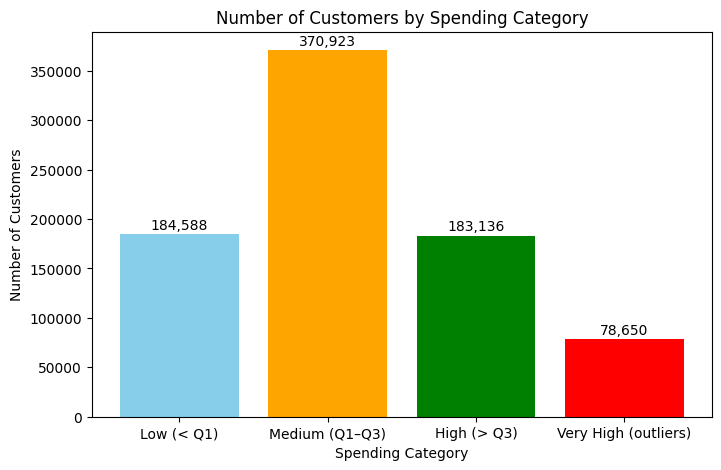

In [ ]:
# Bar chart of customer counts by spending category
categories = ['Low (< Q1)', 'Medium (Q1–Q3)', 'High (> Q3)', 'Very High (outliers)']
values = [low_spenders, mid_spenders, high_spenders, outliers_total_count]
colors = ['skyblue', 'orange', 'green', 'red']

plt.figure(figsize=(8,5))
bars = plt.bar(categories, values, color=colors)

# Addition of value labels above bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 2000, f'{yval:,}', ha='center', va='bottom')

plt.xlabel('Spending Category')
plt.ylabel('Number of Customers')
plt.title('Number of Customers by Spending Category')
plt.show()

In [ ]:
# Mean transaction value per spending group
low_avg = average[total < Q1].mean()
mid_avg = average[(total >= Q1) & (total <= Q3)].mean()
high_avg = average[total > Q3].mean()
very_high_avg = average[outliers_total].mean()

summary = pd.DataFrame({
    'Spending Category': ['Low (< Q1)', 'Medium (Q1–Q3)', 'High (> Q3)', 'Very High (outliers)'],
    'Number of Customers': [low_spenders, mid_spenders, high_spenders, outliers_total_count],
    'Mean transaction value': [round(low_avg, 2), round(mid_avg, 2), round(high_avg, 2), round(very_high_avg, 2)]
})
print(summary)

      Spending Category  Number of Customers  Mean transaction value
0            Low (< Q1)               184588                   71.98
1        Medium (Q1–Q3)               370923                  518.94
2           High (> Q3)               183136                 5203.42
3  Very High (outliers)                78650                 9697.18


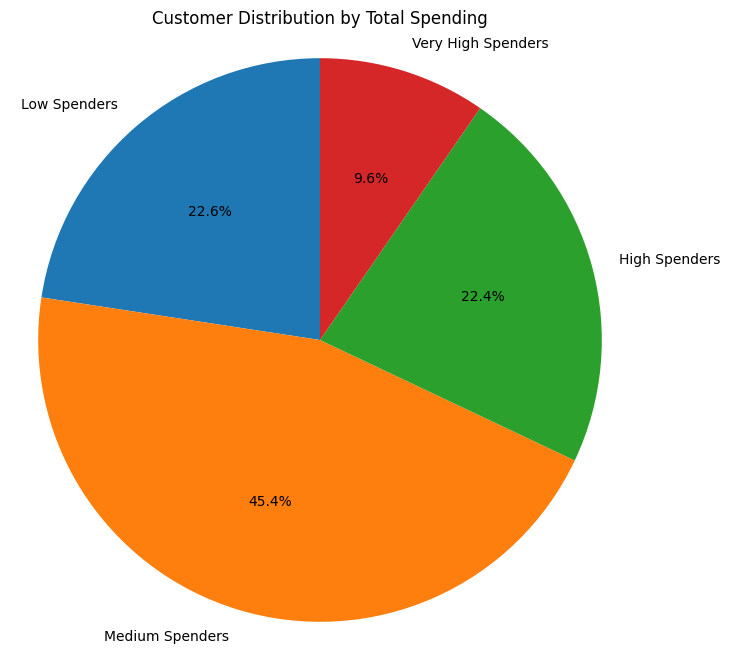

In [ ]:
# Pie chart of spending categories
values1 = [low_spenders, mid_spenders, high_spenders, outliers_total_count]
labels1 = ["Low Spenders", "Medium Spenders", "High Spenders", "Very High Spenders"]

plt.figure(figsize=(8,8))
plt.pie(values1, labels=labels1, autopct='%1.1f%%', startangle=90)
plt.title('Customer Distribution by Total Spending')
plt.axis('equal')
plt.show()

# Typical Transaction Times (e.g., Morning, Evening Activity)

In [ ]:
df['transaction_time'] = pd.to_datetime(df['transaction_time'], format='%H:%M:%S')
df['hour'] = df['transaction_time'].dt.hour

# Function to classify transactions by time period
def time_period(hour):
    if 4 <= hour < 8:
        return 'Early Morning (04–08)'
    elif 8 <= hour < 12:
        return 'Morning (08–12)'
    elif 12 <= hour < 16:
        return 'Midday/Afternoon (12–16)'
    elif 16 <= hour < 20:
        return 'Evening (16–20)'
    elif 20 <= hour < 24:
        return 'Night (20–00)'
    else:
        return 'Late Night (00–04)'

# Application of time classification
df['transaction_time_category'] = df['hour'].apply(time_period)

# Definition of ordered categories
categories = [
    'Late Night (00–04)',
    'Early Morning (04–08)',
    'Morning (08–12)',
    'Midday/Afternoon (12–16)',
    'Evening (16–20)',
    'Night (20–00)'
]

df['transaction_time_category'] = pd.Categorical(
    df['transaction_time_category'],
    categories=categories,
    ordered=True
)

# Summarization of transactions by time category
time_counts = df['transaction_time_category'].value_counts().sort_index()
time_percent = (time_counts / time_counts.sum()) * 100

time_summary = pd.DataFrame({
    'Transaction Count': time_counts,
    'Percentage (%)': time_percent.round(2)
})
print(time_summary)


                           Transaction Count  Percentage (%)
transaction_time_category                                   
Late Night (00–04)                     26268            3.55
Early Morning (04–08)                  23000            3.11
Morning (08–12)                       106625           14.41
Midday/Afternoon (12–16)              181478           24.53
Evening (16–20)                       216653           29.28
Night (20–00)                         185875           25.12


/tmp/ipykernel_29507/2643296251.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend().remove()


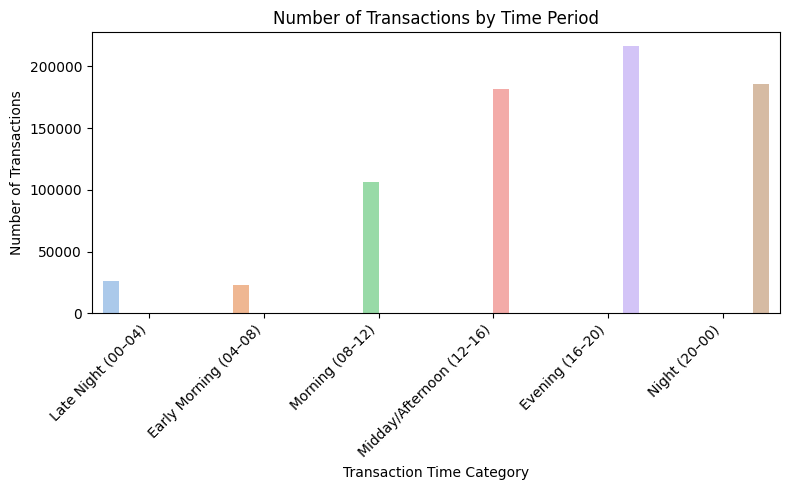

In [ ]:
# Bar plot of transactions by time period
plt.figure(figsize=(8,5))
sns.countplot(
    x='transaction_time_category',
    hue='transaction_time_category',
    data=df,
    order=df['transaction_time_category'].cat.categories,
    palette='pastel'
)
plt.xlabel('Transaction Time Category')
plt.ylabel('Number of Transactions')
plt.title('Number of Transactions by Time Period')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.legend().remove()  
plt.show()

# Demografic analysis

## Age

In [ ]:
from datetime import datetime

# Parsing of dates and correction of unrealistic future dates
df['transaction_date'] = pd.to_datetime(df['transaction_date'], errors='coerce', dayfirst=True)
df['transaction_date'] = df['transaction_date'].apply(lambda x: x - pd.DateOffset(years=100) if x > datetime.now() else x)

df['customer_date_of_birth'] = pd.to_datetime(df['customer_date_of_birth'], errors='coerce', dayfirst=True)
df['customer_date_of_birth'] = df['customer_date_of_birth'].apply(lambda x: x - pd.DateOffset(years=100) if x > datetime.now() else x)


In [ ]:
# Dropping of invalid dates
df = df.dropna(subset=['customer_date_of_birth', 'transaction_date'])

In [ ]:
# Computation of age
df['age'] = df['transaction_date'].dt.year - df['customer_date_of_birth'].dt.year

In [ ]:
df[df['age'] > 100].head()

,transaction_id,customer_id,customer_date_of_birth,cust_gender,cust_location,cust_account_balance,transaction_date,transaction_time,transaction_amount_inr,customer_freq,avg_txn_amount,total_txn_amount,hour,transaction_time_category,age
16,T17,C1376215,1800-01-01,M,MUMBAI,77495.15,2016-08-01,1900-01-01 12:47:27,1423.11,1,1423.11,1423.11,12,Midday/Afternoon (12–16),216
22,T23,C7018081,1800-01-01,M,WAYS PANCHKUVA AHMEDABAD,143.07,2016-08-03,1900-01-01 10:47:18,110.00,1,110.00,110.00,10,Morning (08–12),216
28,T29,C7935438,1800-01-01,M,MOHALI,969436.12,2016-08-03,1900-01-01 18:36:34,36.90,1,36.90,36.90,18,Evening (16–20),216
34,T36,C1211387,1800-01-01,M,AHMEDABAD,11791.25,2016-08-03,1900-01-01 12:59:15,1075.00,1,1075.00,1075.00,12,Midday/Afternoon (12–16),216
150,T152,C3334638,1800-01-01,M,PUNE,700.00,2016-08-09,1900-01-01 02:49:12,1500.00,1,1500.00,1500.00,2,Late Night (00–04),216


In [ ]:
df[df['age'] > 100].shape

# ini tidak realistic, karena kita perlu umur juga dan kita 

(40601, 15)

In [ ]:
df[df['age'] < 0].head()

,transaction_id,customer_id,customer_date_of_birth,cust_gender,cust_location,cust_account_balance,transaction_date,transaction_time,transaction_amount_inr,customer_freq,avg_txn_amount,total_txn_amount,hour,transaction_time_category,age
1324,T1329,C6417656,2021-01-19,M,NEW DELHI,1125922.25,2016-10-21,1900-01-01 19:27:55,6300.00,1,6300.00,6300.00,19,Evening (16–20),-5
1662,T1668,C4217631,2021-01-19,M,NEW DELHI,1125922.25,2016-10-21,1900-01-01 19:57:48,2460.00,1,2460.00,2460.00,19,Evening (16–20),-5
25989,T26155,C4925544,2019-12-15,F,DELHI,27081.15,2016-09-26,1900-01-01 17:33:00,12580.29,1,12580.29,12580.29,17,Evening (16–20),-3
92394,T93054,C4517661,2021-01-19,M,NEW DELHI,1125922.25,2016-09-27,1900-01-01 20:59:16,957.00,1,957.00,957.00,20,Night (20–00),-5
152268,T153362,C7017646,2021-01-19,M,NEW DELHI,1125922.25,2016-08-05,1900-01-01 21:03:10,995.00,1,995.00,995.00,21,Night (20–00),-5


In [ ]:
df[df['age'] < 0].head()

,transaction_id,customer_id,customer_date_of_birth,cust_gender,cust_location,cust_account_balance,transaction_date,transaction_time,transaction_amount_inr,customer_freq,avg_txn_amount,total_txn_amount,hour,transaction_time_category,age
1324,T1329,C6417656,2021-01-19,M,NEW DELHI,1125922.25,2016-10-21,1900-01-01 19:27:55,6300.00,1,6300.00,6300.00,19,Evening (16–20),-5
1662,T1668,C4217631,2021-01-19,M,NEW DELHI,1125922.25,2016-10-21,1900-01-01 19:57:48,2460.00,1,2460.00,2460.00,19,Evening (16–20),-5
25989,T26155,C4925544,2019-12-15,F,DELHI,27081.15,2016-09-26,1900-01-01 17:33:00,12580.29,1,12580.29,12580.29,17,Evening (16–20),-3
92394,T93054,C4517661,2021-01-19,M,NEW DELHI,1125922.25,2016-09-27,1900-01-01 20:59:16,957.00,1,957.00,957.00,20,Night (20–00),-5
152268,T153362,C7017646,2021-01-19,M,NEW DELHI,1125922.25,2016-08-05,1900-01-01 21:03:10,995.00,1,995.00,995.00,21,Night (20–00),-5


In [ ]:
df[df['age'] < 0].shape

(37, 15)

In [ ]:
# Dropping of invalid dates
df = df.dropna(subset=['customer_date_of_birth', 'transaction_date'])

# Removal of unrealistic ages
df = df[(df['age'] >= 0) & (df['age'] <= 100)]

In [ ]:
# keeping one record per customer
customer_demo = (
    df.groupby('customer_id', dropna=False)
    .agg(
        cust_location=('cust_location', lambda x: x.mode().iat[0] if not x.mode().empty else x.iloc[0]),
        age=('age', 'first')
    )
    .reset_index()
)

In [ ]:
# merge lagi

df = df.drop(columns=['age'], errors='ignore')
df = df.merge(customer_demo[['customer_id', 'age']], on='customer_id', how='left')

print("Added 'age' column successfully.")
print(df[['customer_id', 'age']].head(10))
print("Number of unique customers:", df['customer_id'].nunique())

Added 'age' column successfully.
  customer_id  age
0    C5841053   22
1    C2142763   59
2    C4417068   20
3    C9031234   28
4    C1536588   44
5    C1220223   34
6    C8536061   28
7    C6638934   32
8    C6939838   28
9    C6339347   38
Number of unique customers: 698393


/tmp/ipykernel_29507/2023692428.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=age_counts.index, y=age_counts.values, palette='pastel')


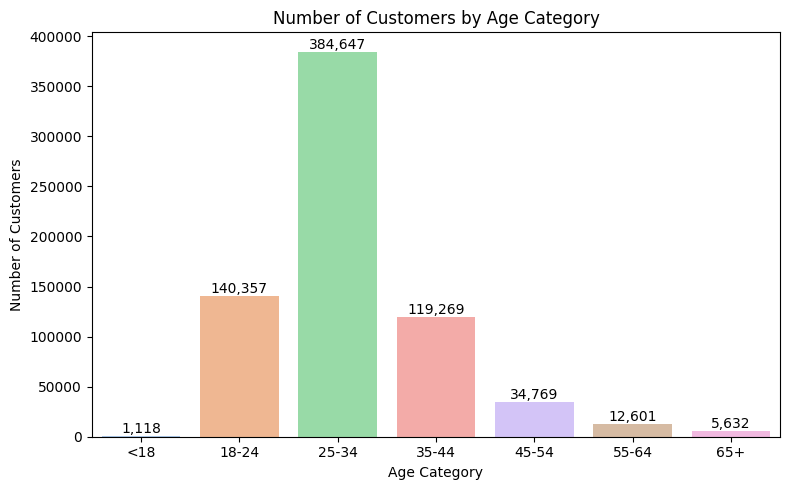

In [ ]:
# --- Age Categories and Bar Plot ---
bins = [0, 18, 25, 35, 45, 55, 65, 100]
labels = ['<18', '18-24', '25-34', '35-44', '45-54', '55-64', '65+']
df['age_category'] = pd.cut(df['age'], bins=bins, labels=labels, right=False)

age_counts = df.groupby('age_category')['customer_id'].nunique()

plt.figure(figsize=(8,5))
sns.barplot(x=age_counts.index, y=age_counts.values, palette='pastel')
for i, v in enumerate(age_counts.values):
    plt.text(i, v + 50, f'{v:,}', ha='center', va='bottom')
plt.xlabel('Age Category')
plt.ylabel('Number of Customers')
plt.title('Number of Customers by Age Category')
plt.tight_layout()
plt.show()

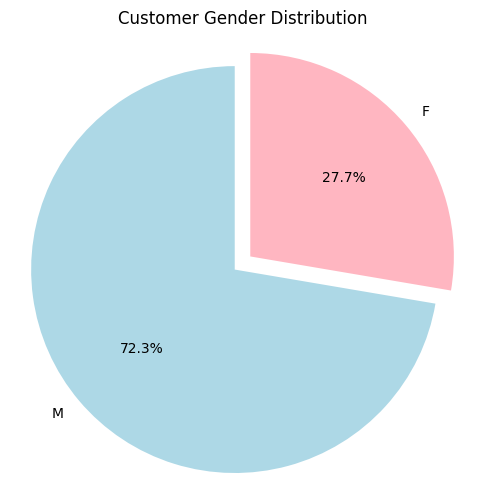

In [ ]:
# 3.2. Gender (cust_gender)
# Pie chart comparing number of customers by gender (ignore single 'T' entry)

# Filter only 'M' and 'F'
gender_counts = df[df['cust_gender'].isin(['M', 'F'])]['cust_gender'].value_counts()

# Pie chart
colors = ['lightblue', 'lightpink']
plt.figure(figsize=(6,6))
plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    explode=(0.05, 0.05)
)
plt.title('Customer Gender Distribution')
plt.axis('equal')
plt.show()

/tmp/ipykernel_29507/3097604175.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=location_counts.index, y=location_counts.values, palette='pastel')


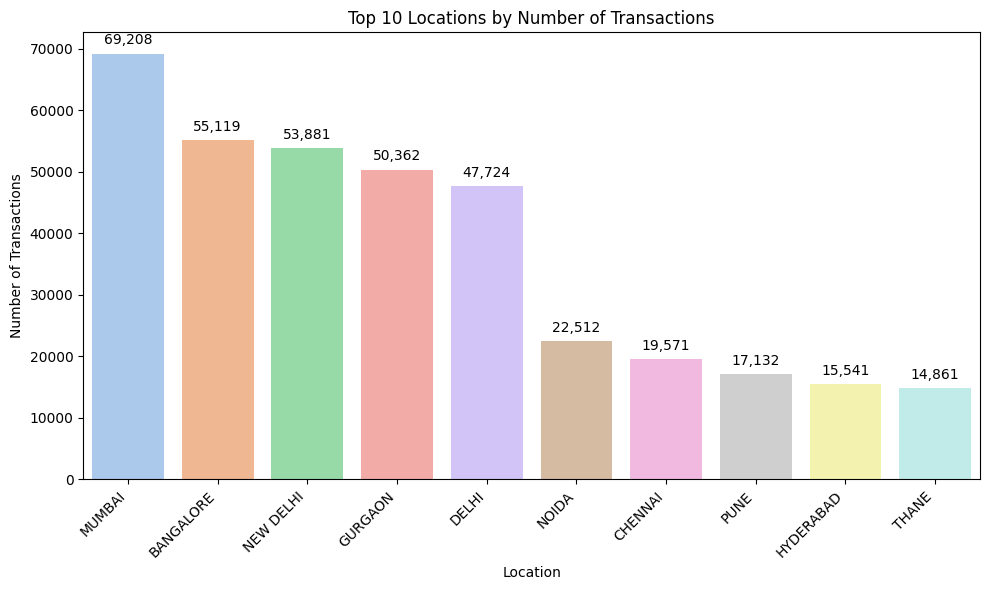

In [ ]:
# 3.3. Location (cust_location)
# Bar chart showing top 10 locations by number of transactions
# Count of transactions per location
location_counts = df['cust_location'].value_counts().head(10)

# Bar chart
plt.figure(figsize=(10,6))
sns.barplot(x=location_counts.index, y=location_counts.values, palette='pastel')

# Addition of transaction counts above bars
for i, v in enumerate(location_counts.values):
    plt.text(i, v + 1000, f'{v:,}', ha='center', va='bottom')

plt.xlabel('Location')
plt.ylabel('Number of Transactions')
plt.title('Top 10 Locations by Number of Transactions')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# checking distribution

In [ ]:
def check_distribution(df, column_name):
    """
    Generalized function to check distribution, missing values, 
    and outliers for any column.
    """
    if column_name not in df.columns:
        print(f"Error: Column '{column_name}' not found in DataFrame.")
        return

    # 1. Basic Stats & Info
    print(f"📊 --- Exploration: {column_name} ---")
    print(f"Data Type: {df[column_name].dtype}")
    print(f"Missing Values: {df[column_name].isnull().sum()} ({df[column_name].isnull().mean()*100:.2f}%)")
    print(f"Unique Values: {df[column_name].nunique()}")

    # 2. Logic for Numerical Data (Age, Balance, Amount)
    if pd.api.types.is_numeric_dtype(df[column_name]):
        print("\n--- Summary Statistics ---")
        print(df[column_name].describe())
        
        # Premium Visualization
        plt.figure(figsize=(14, 5))
        
        # Histogram + KDE
        plt.subplot(1, 2, 1)
        sns.histplot(df[column_name], kde=True, color='#4e79a7', bins=30)
        plt.title(f'Distribution of {column_name}', fontsize=14)
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        
        # Boxplot for Outliers
        plt.subplot(1, 2, 2)
        sns.boxplot(x=df[column_name], color='#e15759', fliersize=5)
        plt.title(f'Outlier Check: {column_name}', fontsize=14)
        
        plt.tight_layout()
        plt.show()

    # 3. Logic for Categorical Data (Gender, Location, Time Category)
    else:
        print("\n--- Value Counts (Top 10) ---")
        counts = df[column_name].value_counts().head(10)
        print(counts)
        
        plt.figure(figsize=(10, 6))
        sns.barplot(x=counts.index, y=counts.values, palette='viridis')
        plt.title(f'Top 10 Frequency Distribution: {column_name}', fontsize=14)
        plt.ylabel('Count')
        plt.xticks(rotation=45)
        plt.grid(axis='y', linestyle='--', alpha=0.5)
        plt.show()


In [ ]:
df[df['cust_account_balance'] < 0]

,transaction_id,customer_id,customer_date_of_birth,cust_gender,cust_location,cust_account_balance,transaction_date,transaction_time,transaction_amount_inr,customer_freq,avg_txn_amount,total_txn_amount,hour,transaction_time_category,age,age_category


📊 --- Exploration: cust_account_balance ---
Data Type: float64
Missing Values: 0 (0.00%)
Unique Values: 138579

--- Summary Statistics ---
count    6.992610e+05
mean     1.053671e+05
std      8.086395e+05
min      0.000000e+00
25%      4.575650e+03
50%      1.601141e+04
75%      5.375908e+04
max      1.150355e+08
Name: cust_account_balance, dtype: float64


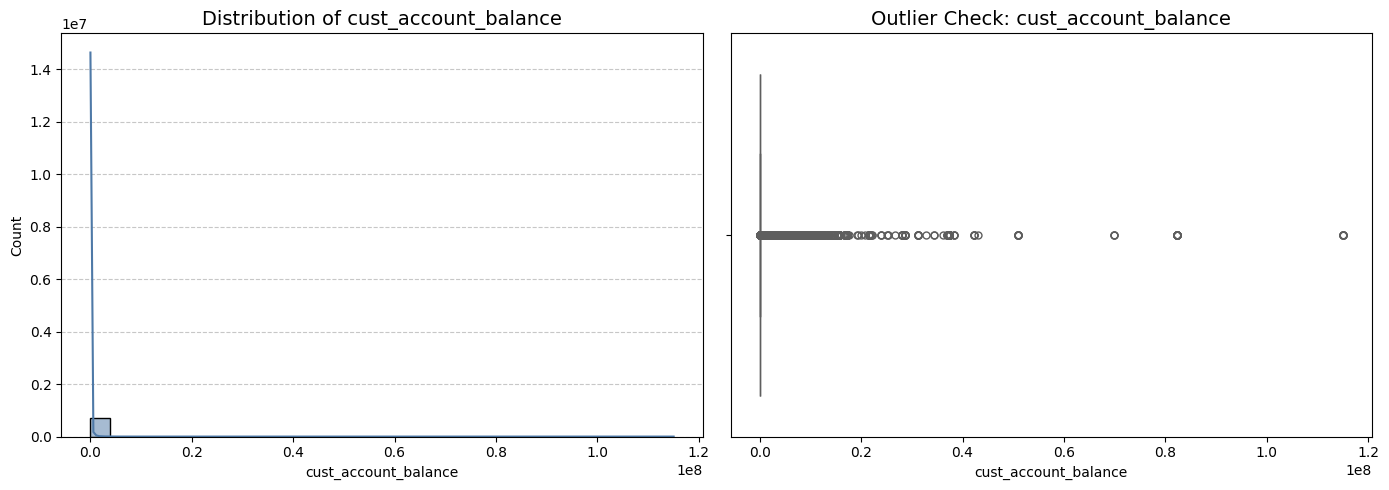

In [ ]:
check_distribution(df, 'cust_account_balance')

<Axes: >

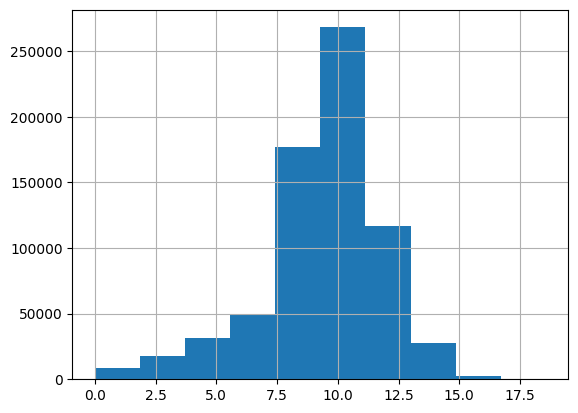

In [ ]:
np.log1p(df['cust_account_balance']).hist()

In [ ]:
from sklearn.preprocessing import PowerTransformer
# This will automatically find the best way to make the data "Normal"
pt = PowerTransformer(method='yeo-johnson')


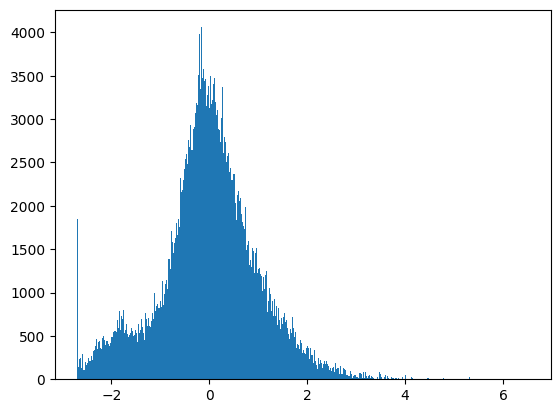

In [ ]:
plt.hist(pt.fit_transform(df[['cust_account_balance']]), bins=1000)
plt.show()

In [ ]:
df['cust_account_balance_normalized'] = pt.fit_transform(df[['cust_account_balance']])

📊 --- Exploration: cust_account_balance_normalized ---
Data Type: float64
Missing Values: 0 (0.00%)
Unique Values: 138579

--- Summary Statistics ---
count    6.992610e+05
mean    -1.742873e-16
std      1.000001e+00
min     -2.696862e+00
25%     -5.247379e-01
50%     -4.165363e-03
75%      5.690037e-01
max      6.517157e+00
Name: cust_account_balance_normalized, dtype: float64


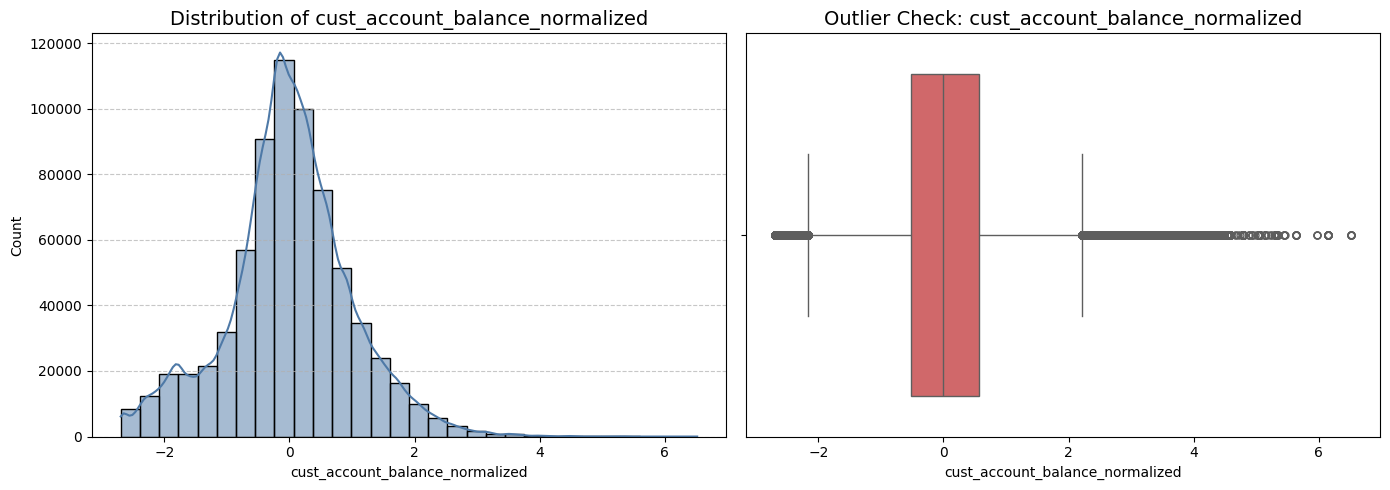

In [ ]:
check_distribution(df, 'cust_account_balance_normalized')

In [ ]:
df[df['transaction_amount_inr'] < 0]

,transaction_id,customer_id,customer_date_of_birth,cust_gender,cust_location,cust_account_balance,transaction_date,transaction_time,transaction_amount_inr,customer_freq,avg_txn_amount,total_txn_amount,hour,transaction_time_category,age,age_category,cust_account_balance_normalized


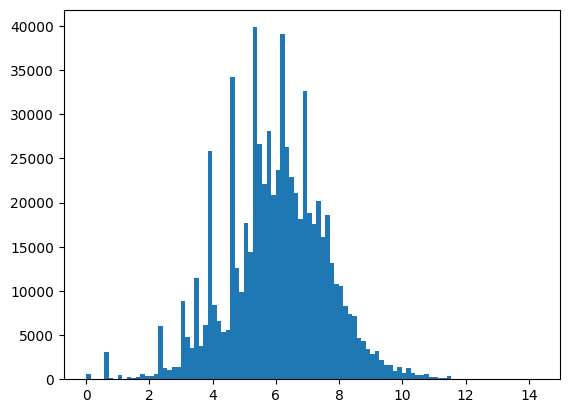

In [ ]:
plt.hist(np.log1p(df[['transaction_amount_inr']]), bins=100)
plt.show()

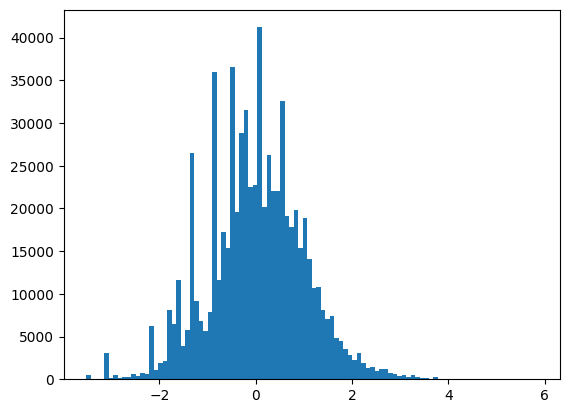

In [ ]:
pt = PowerTransformer(method='yeo-johnson')

plt.hist(pt.fit_transform(df[['transaction_amount_inr']]), bins=100)
plt.show()

In [ ]:
df['transaction_amount_inr_normalized'] = pt.transform(df[['transaction_amount_inr']])

📊 --- Exploration: transaction_amount_inr_normalized ---
Data Type: float64
Missing Values: 0 (0.00%)
Unique Values: 68243

--- Summary Statistics ---
count    6.992610e+05
mean    -3.693850e-16
std      1.000001e+00
min     -3.521365e+00
25%     -6.304965e-01
50%      1.763171e-02
75%      6.335622e-01
max      5.839879e+00
Name: transaction_amount_inr_normalized, dtype: float64


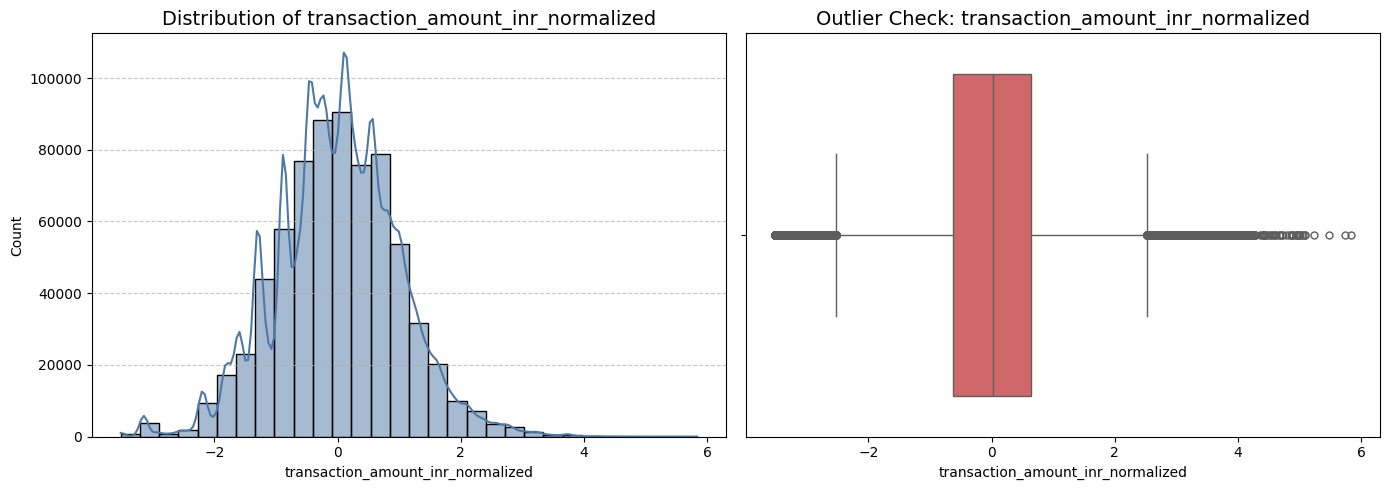

In [ ]:
check_distribution(df, 'transaction_amount_inr_normalized')

In [ ]:
df.head()

,transaction_id,customer_id,customer_date_of_birth,cust_gender,cust_location,cust_account_balance,transaction_date,transaction_time,transaction_amount_inr,customer_freq,avg_txn_amount,total_txn_amount,hour,transaction_time_category,age,age_category,cust_account_balance_normalized,transaction_amount_inr_normalized
0,T1,C5841053,1994-01-10,F,JAMSHEDPUR,17819.05,2016-08-02,1900-01-01 14:32:07,25.0,1,25.0,25.0,14,Midday/Afternoon (12–16),22,18-24,0.043560,-1.695121
1,T2,C2142763,1957-04-04,M,JHAJJAR,2270.69,2016-08-02,1900-01-01 14:18:58,27999.0,1,27999.0,27999.0,14,Midday/Afternoon (12–16),59,55-64,-0.787293,2.818036
2,T3,C4417068,1996-11-26,F,MUMBAI,17874.44,2016-08-02,1900-01-01 14:27:12,459.0,1,459.0,459.0,14,Midday/Afternoon (12–16),20,18-24,0.044953,0.057444
3,T5,C9031234,1988-03-24,F,NAVI MUMBAI,6714.43,2016-08-02,1900-01-01 18:11:56,1762.5,1,1762.5,1762.5,18,Evening (16–20),28,25-34,-0.372588,0.926114
4,T6,C1536588,1972-10-08,F,ITANAGAR,53609.20,2016-08-02,1900-01-01 17:39:40,676.0,1,676.0,676.0,17,Evening (16–20),44,35-44,0.567597,0.303955


📊 --- Exploration: age_category ---
Data Type: category
Missing Values: 0 (0.00%)
Unique Values: 7

--- Value Counts (Top 10) ---
age_category
25-34    385139
18-24    140524
35-44    119421
45-54     34805
55-64     12615
65+        5638
<18        1119
Name: count, dtype: int64


/tmp/ipykernel_29507/3805595410.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette='viridis')


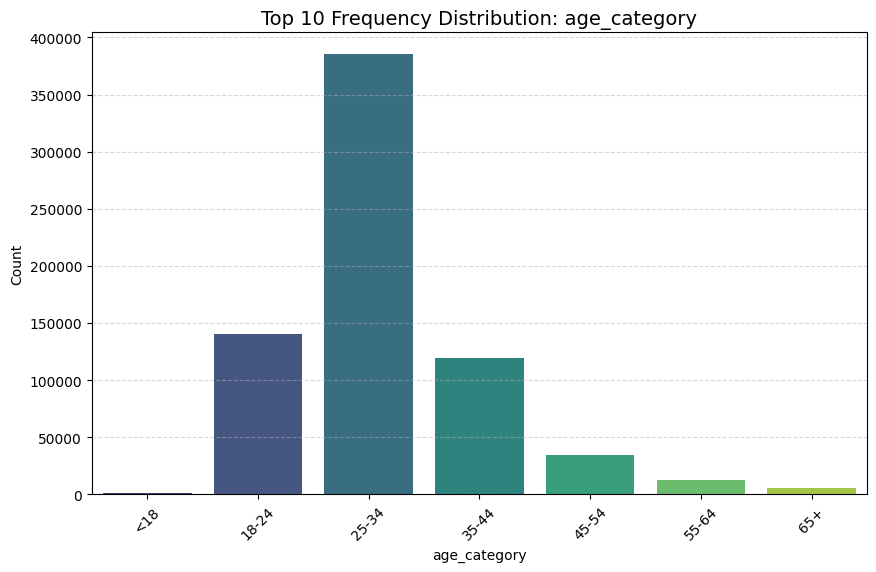

In [ ]:
check_distribution(df, 'age_category')

📊 --- Exploration: transaction_id ---
Data Type: str
Missing Values: 0 (0.00%)
Unique Values: 699261

--- Value Counts (Top 10) ---
transaction_id
T1     1
T2     1
T3     1
T5     1
T6     1
T8     1
T9     1
T10    1
T12    1
T13    1
Name: count, dtype: int64


/tmp/ipykernel_29507/3805595410.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette='viridis')


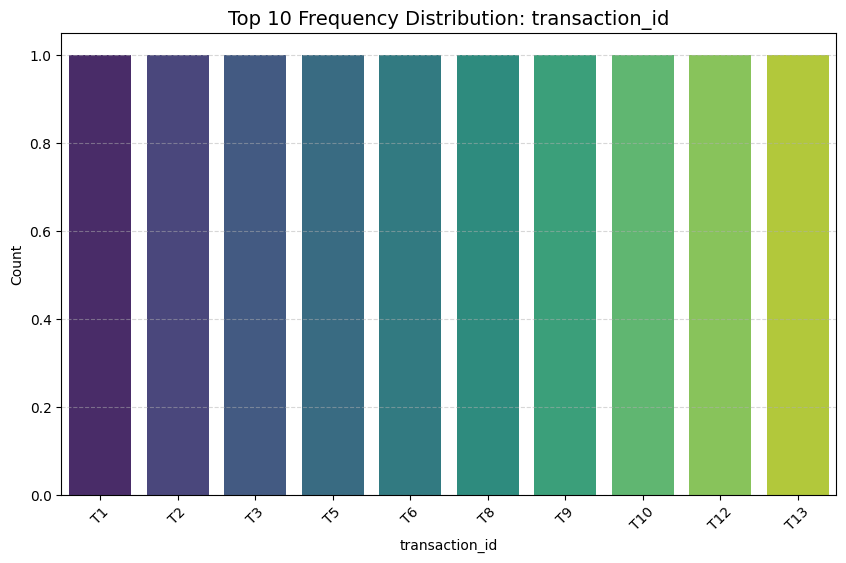

📊 --- Exploration: customer_id ---
Data Type: str
Missing Values: 0 (0.00%)
Unique Values: 698393

--- Value Counts (Top 10) ---
customer_id
C2140114    3
C1224627    3
C3531473    2
C2526046    2
C4740088    2
C8133949    2
C3828120    2
C4610655    2
C8621391    2
C7119088    2
Name: count, dtype: int64


/tmp/ipykernel_29507/3805595410.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette='viridis')


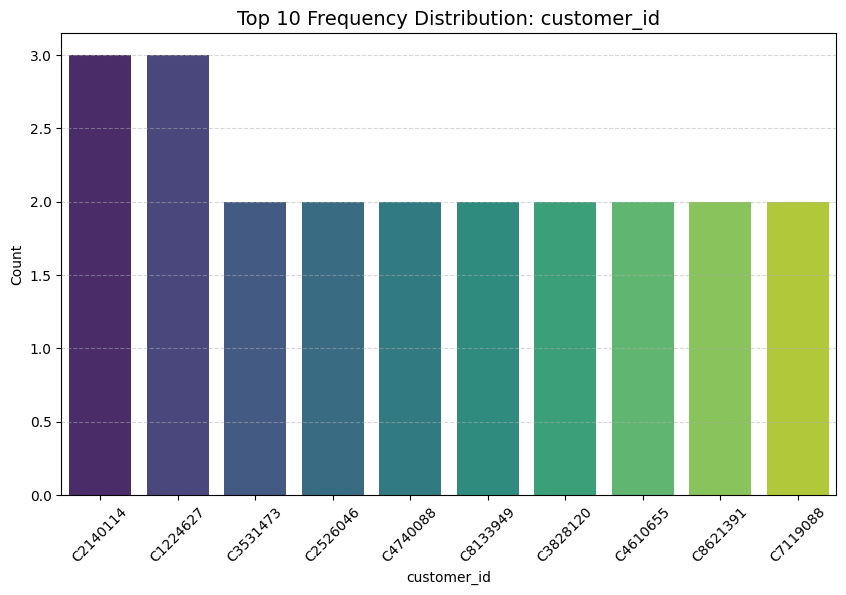

📊 --- Exploration: customer_date_of_birth ---
Data Type: datetime64[us]
Missing Values: 0 (0.00%)
Unique Values: 16718

--- Value Counts (Top 10) ---
customer_date_of_birth
1989-01-01    601
1990-01-01    566
1986-11-21    532
1991-08-06    475
1991-01-01    462
1992-01-01    440
1990-07-01    424
1987-01-01    408
1988-01-01    406
1993-01-01    366
Name: count, dtype: int64


/tmp/ipykernel_29507/3805595410.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette='viridis')


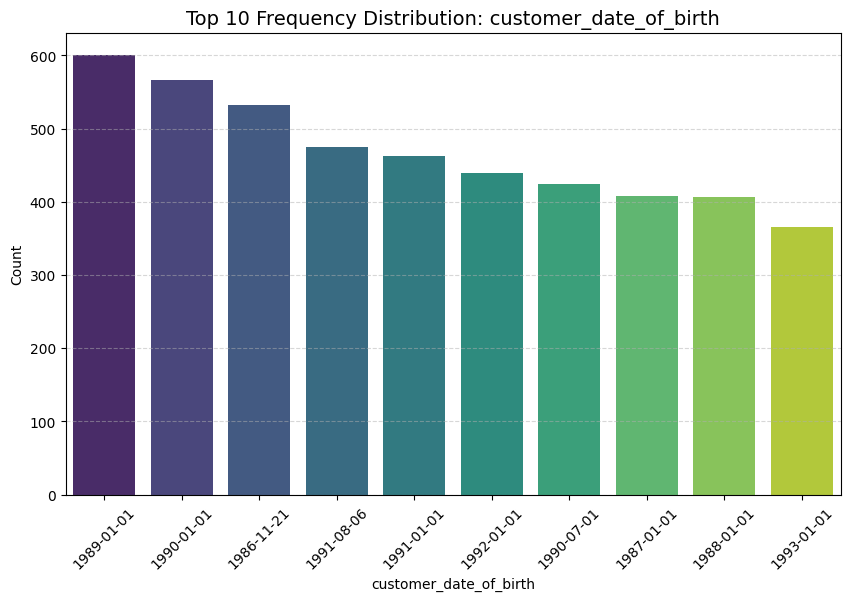

📊 --- Exploration: cust_gender ---
Data Type: str
Missing Values: 0 (0.00%)
Unique Values: 2

--- Value Counts (Top 10) ---
cust_gender
M    505715
F    193546
Name: count, dtype: int64


/tmp/ipykernel_29507/3805595410.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette='viridis')


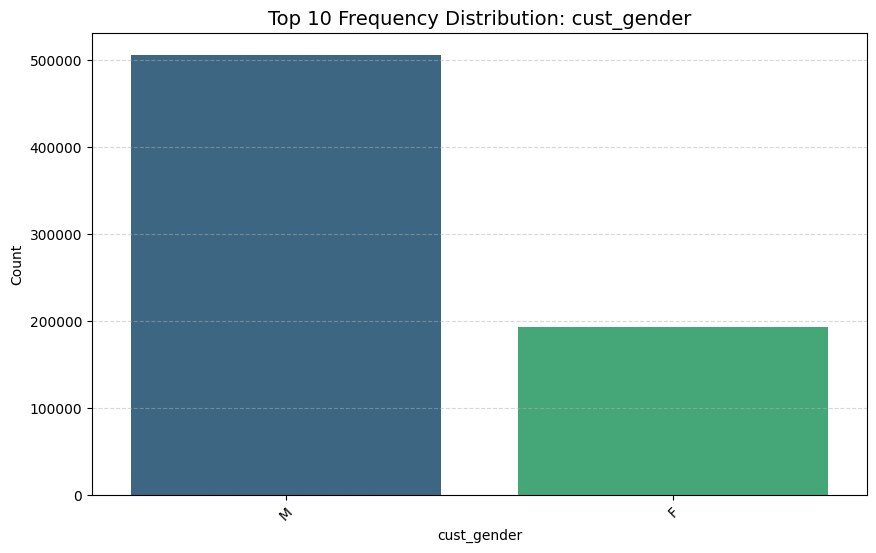

📊 --- Exploration: cust_location ---
Data Type: str
Missing Values: 0 (0.00%)
Unique Values: 7572

--- Value Counts (Top 10) ---
cust_location
MUMBAI       69208
BANGALORE    55119
NEW DELHI    53881
GURGAON      50362
DELHI        47724
NOIDA        22512
CHENNAI      19571
PUNE         17132
HYDERABAD    15541
THANE        14861
Name: count, dtype: int64


/tmp/ipykernel_29507/3805595410.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette='viridis')


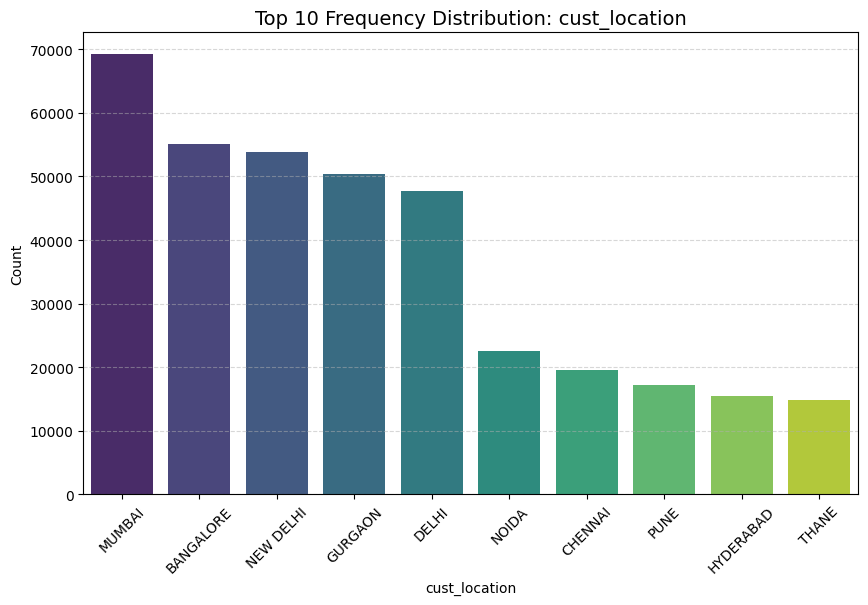

📊 --- Exploration: cust_account_balance ---
Data Type: float64
Missing Values: 0 (0.00%)
Unique Values: 138579

--- Summary Statistics ---
count    6.992610e+05
mean     1.053671e+05
std      8.086395e+05
min      0.000000e+00
25%      4.575650e+03
50%      1.601141e+04
75%      5.375908e+04
max      1.150355e+08
Name: cust_account_balance, dtype: float64


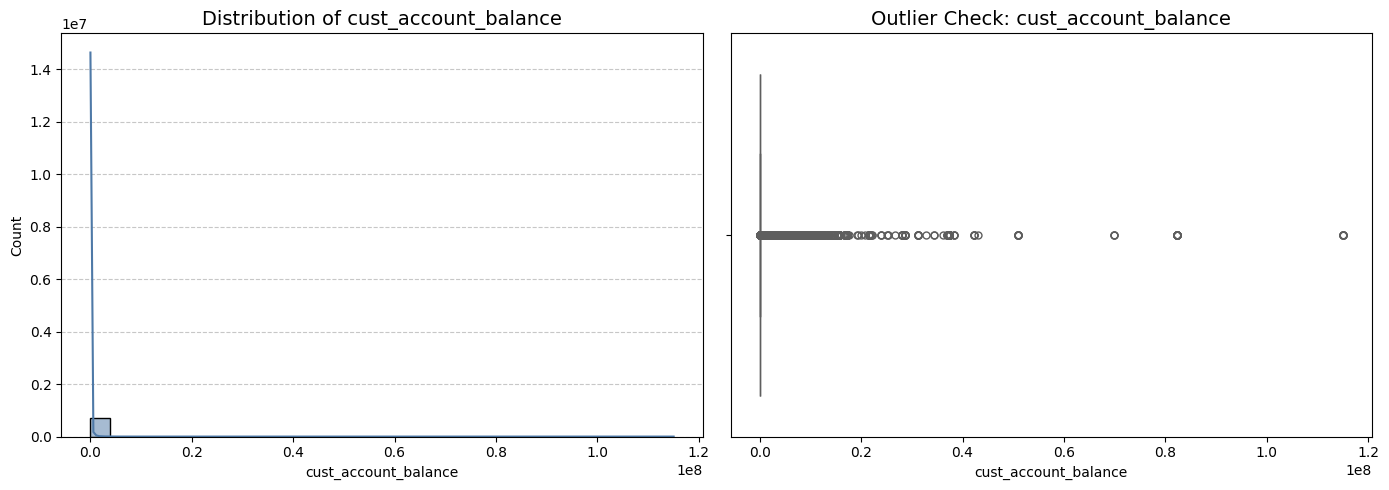

📊 --- Exploration: transaction_date ---
Data Type: datetime64[us]
Missing Values: 0 (0.00%)
Unique Values: 55

--- Value Counts (Top 10) ---
transaction_date
2016-08-07    18447
2016-08-13    18024
2016-08-06    18004
2016-09-04    17936
2016-09-03    17894
2016-09-10    17267
2016-09-11    17192
2016-08-14    17180
2016-08-15    16376
2016-08-21    15386
Name: count, dtype: int64


/tmp/ipykernel_29507/3805595410.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette='viridis')


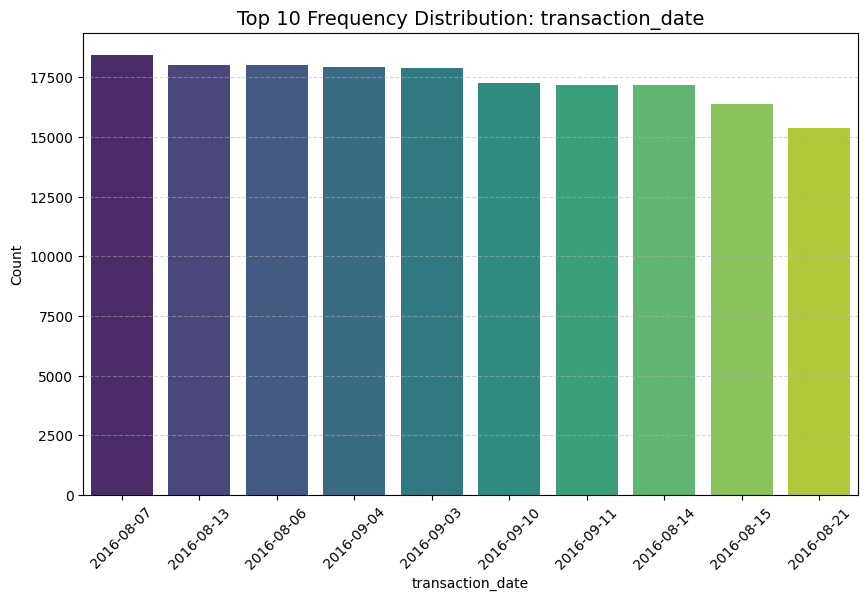

📊 --- Exploration: transaction_time ---
Data Type: datetime64[us]
Missing Values: 0 (0.00%)
Unique Values: 78513

--- Value Counts (Top 10) ---
transaction_time
1900-01-01 19:57:08    37
1900-01-01 20:27:09    36
1900-01-01 20:06:46    35
1900-01-01 19:50:07    34
1900-01-01 20:38:48    34
1900-01-01 20:44:24    34
1900-01-01 20:15:45    33
1900-01-01 19:50:02    33
1900-01-01 20:18:15    33
1900-01-01 20:32:01    32
Name: count, dtype: int64


/tmp/ipykernel_29507/3805595410.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette='viridis')


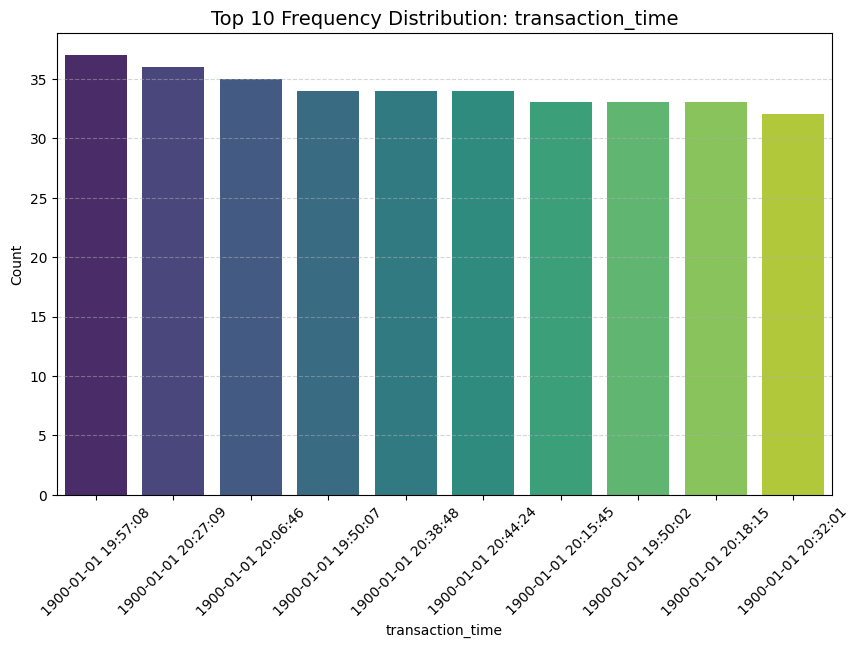

📊 --- Exploration: transaction_amount_inr ---
Data Type: float64
Missing Values: 0 (0.00%)
Unique Values: 68243

--- Summary Statistics ---
count    6.992610e+05
mean     1.454472e+03
std      6.381163e+03
min      0.000000e+00
25%      1.520000e+02
50%      4.310000e+02
75%      1.126800e+03
max      1.560035e+06
Name: transaction_amount_inr, dtype: float64


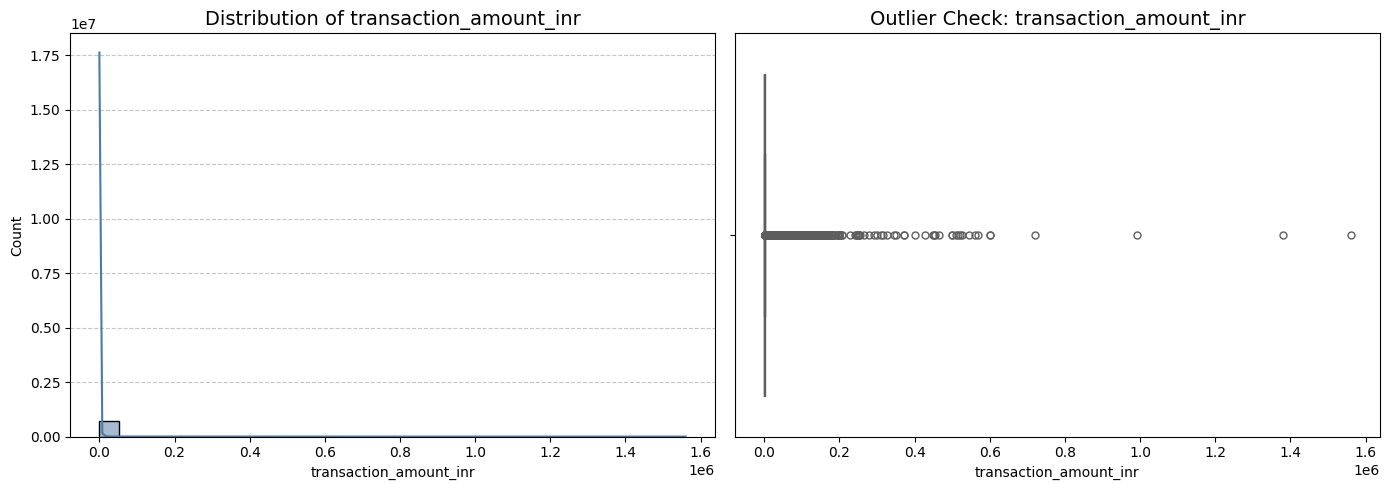

📊 --- Exploration: customer_freq ---
Data Type: int64
Missing Values: 0 (0.00%)
Unique Values: 3

--- Summary Statistics ---
count    699261.000000
mean          1.002488
std           0.049993
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max           3.000000
Name: customer_freq, dtype: float64


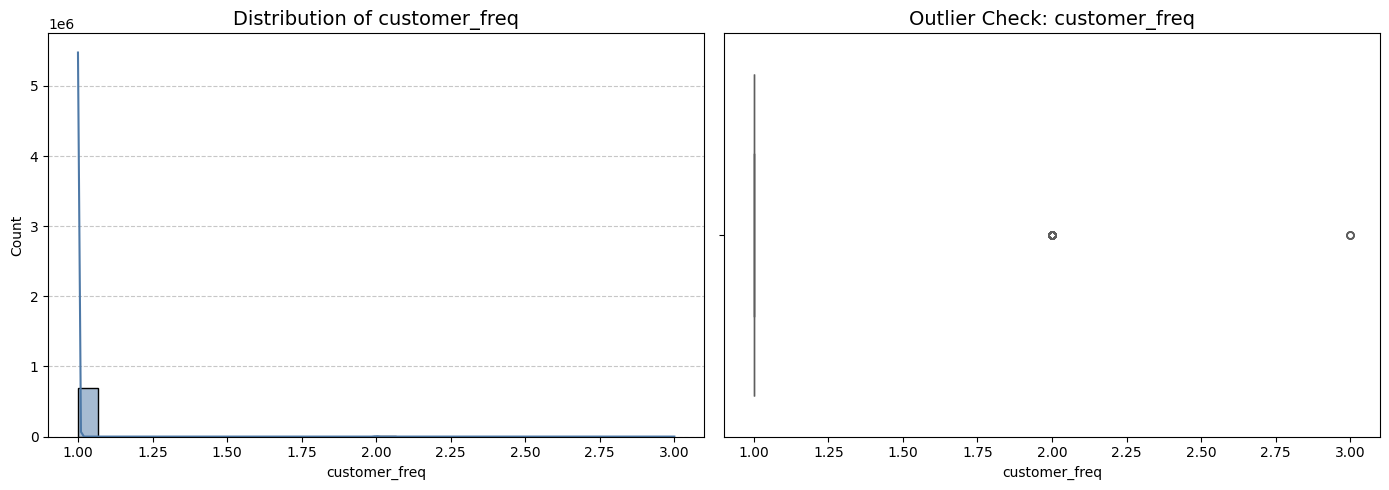

📊 --- Exploration: avg_txn_amount ---
Data Type: float64
Missing Values: 0 (0.00%)
Unique Values: 68337

--- Summary Statistics ---
count    6.992610e+05
mean     1.454472e+03
std      6.380723e+03
min      0.000000e+00
25%      1.530000e+02
50%      4.319700e+02
75%      1.127000e+03
max      1.560035e+06
Name: avg_txn_amount, dtype: float64


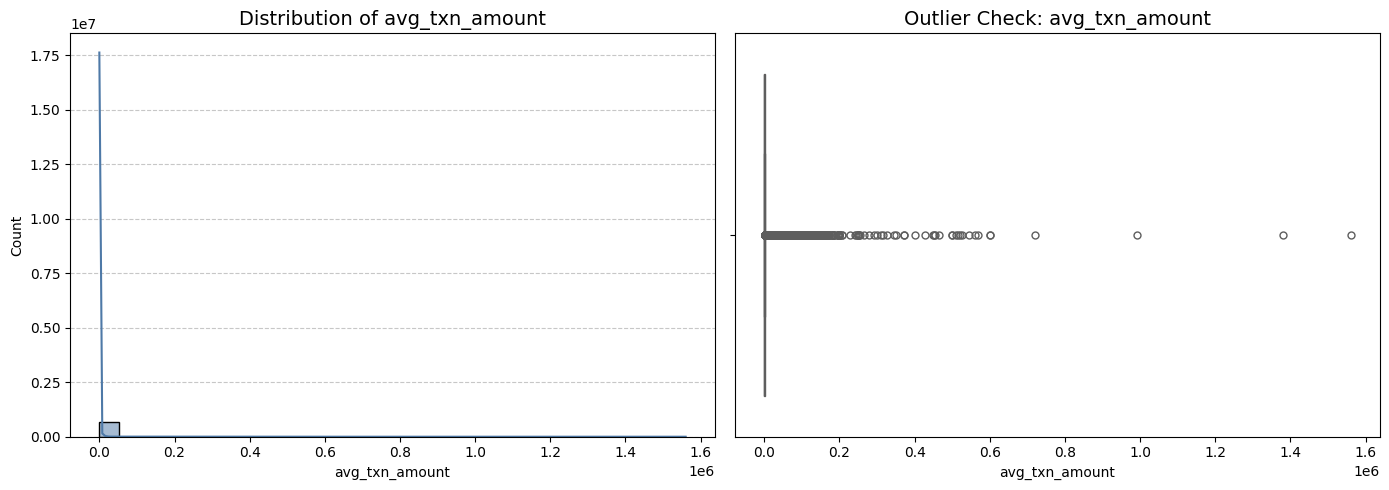

📊 --- Exploration: total_txn_amount ---
Data Type: float64
Missing Values: 0 (0.00%)
Unique Values: 68302

--- Summary Statistics ---
count    6.992610e+05
mean     1.457187e+03
std      6.389142e+03
min      0.000000e+00
25%      1.530000e+02
50%      4.338100e+02
75%      1.131500e+03
max      1.560035e+06
Name: total_txn_amount, dtype: float64


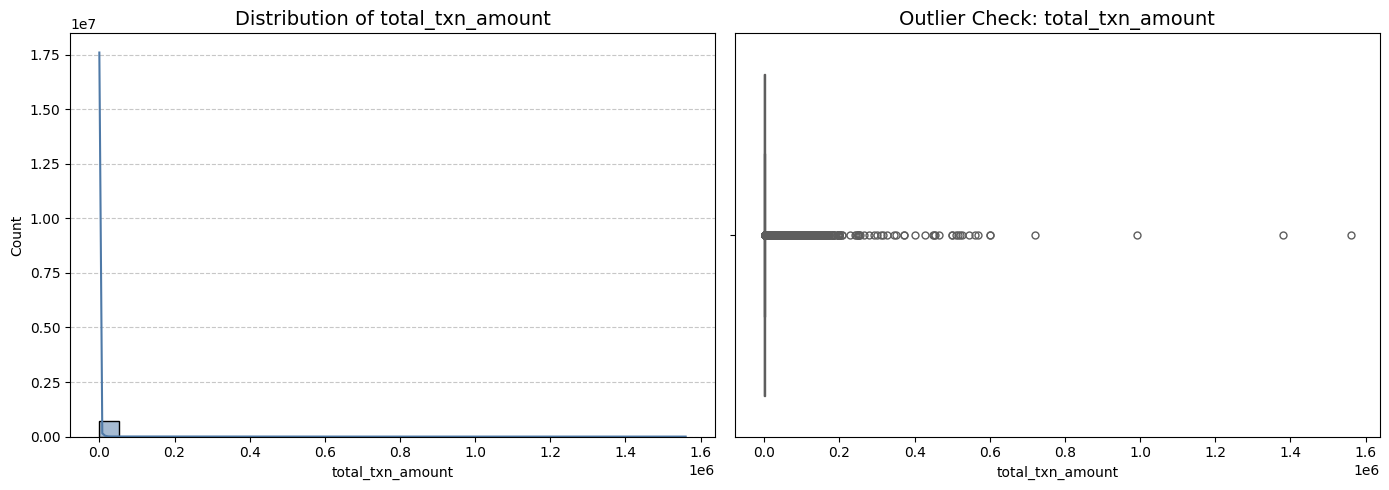

📊 --- Exploration: hour ---
Data Type: int32
Missing Values: 0 (0.00%)
Unique Values: 24

--- Summary Statistics ---
count    699261.000000
mean         15.448243
std           5.130395
min           0.000000
25%          12.000000
50%          16.000000
75%          20.000000
max          23.000000
Name: hour, dtype: float64


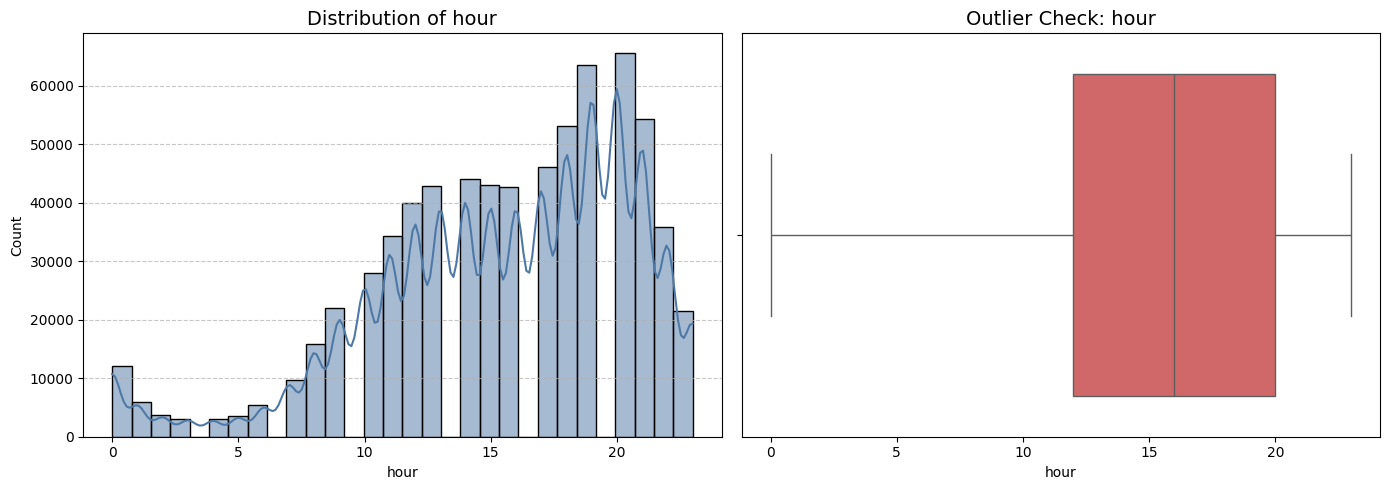

📊 --- Exploration: transaction_time_category ---
Data Type: category
Missing Values: 0 (0.00%)
Unique Values: 6

--- Value Counts (Top 10) ---
transaction_time_category
Evening (16–20)             205472
Night (20–00)               177359
Midday/Afternoon (12–16)    170033
Morning (08–12)             100042
Late Night (00–04)           24688
Early Morning (04–08)        21667
Name: count, dtype: int64


/tmp/ipykernel_29507/3805595410.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette='viridis')


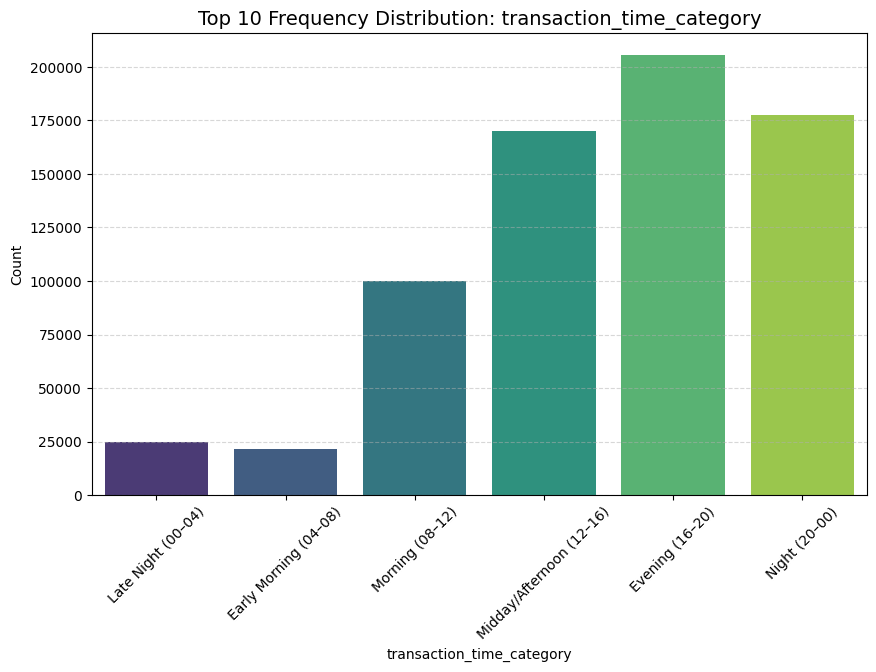

📊 --- Exploration: age ---
Data Type: int32
Missing Values: 0 (0.00%)
Unique Values: 91

--- Summary Statistics ---
count    699261.000000
mean         31.025736
std           8.734361
min           0.000000
25%          25.000000
50%          29.000000
75%          34.000000
max          90.000000
Name: age, dtype: float64


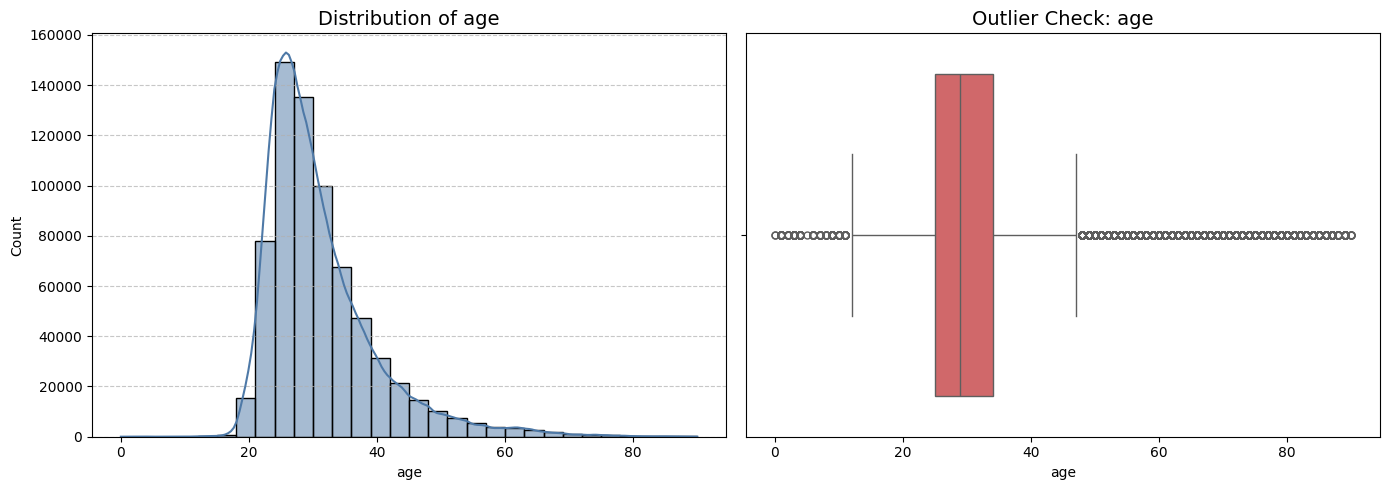

📊 --- Exploration: age_category ---
Data Type: category
Missing Values: 0 (0.00%)
Unique Values: 7

--- Value Counts (Top 10) ---
age_category
25-34    385139
18-24    140524
35-44    119421
45-54     34805
55-64     12615
65+        5638
<18        1119
Name: count, dtype: int64


/tmp/ipykernel_29507/3805595410.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette='viridis')


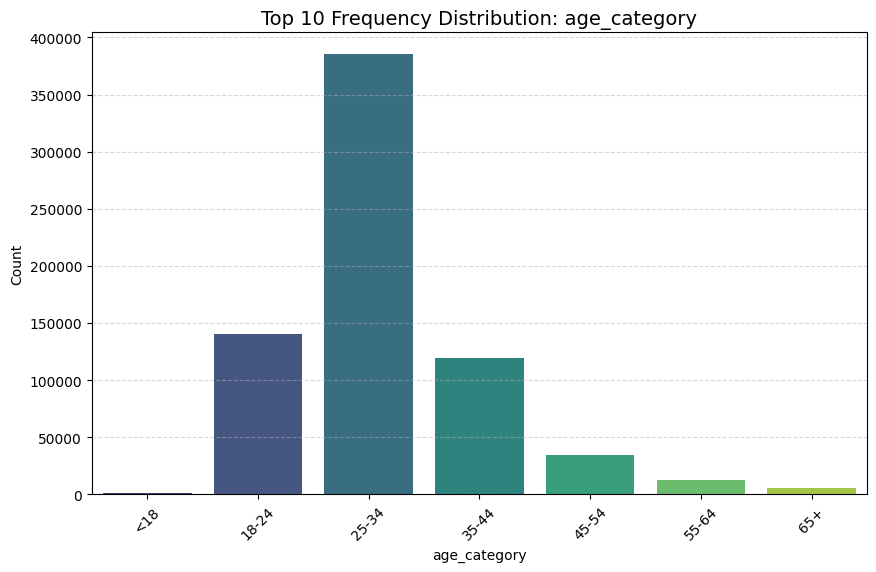

📊 --- Exploration: cust_account_balance_normalized ---
Data Type: float64
Missing Values: 0 (0.00%)
Unique Values: 138579

--- Summary Statistics ---
count    6.992610e+05
mean    -1.742873e-16
std      1.000001e+00
min     -2.696862e+00
25%     -5.247379e-01
50%     -4.165363e-03
75%      5.690037e-01
max      6.517157e+00
Name: cust_account_balance_normalized, dtype: float64


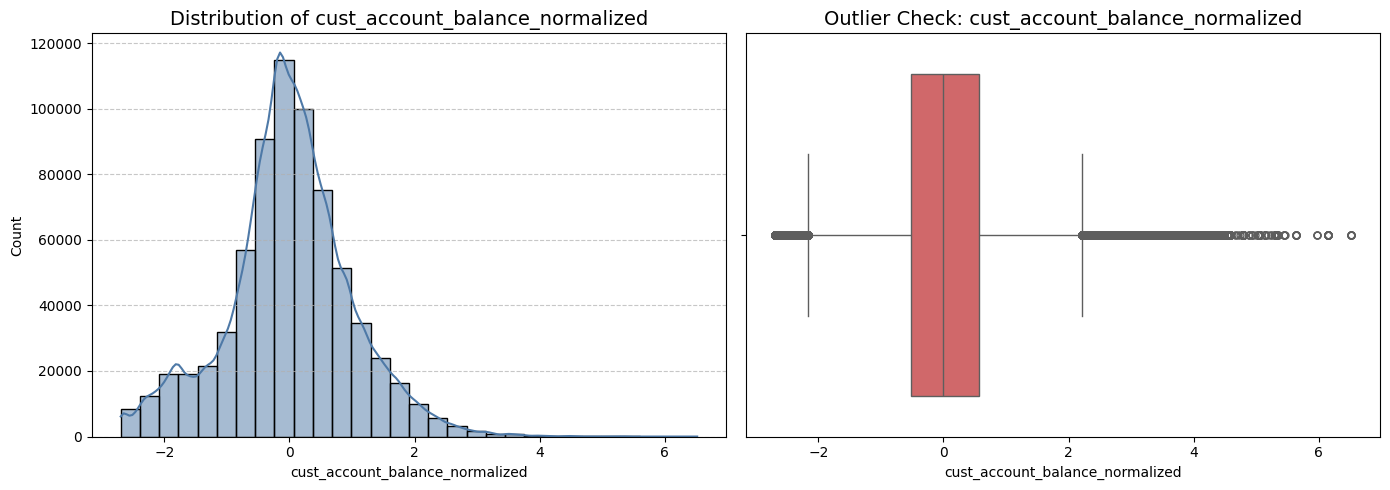

📊 --- Exploration: transaction_amount_inr_normalized ---
Data Type: float64
Missing Values: 0 (0.00%)
Unique Values: 68243

--- Summary Statistics ---
count    6.992610e+05
mean    -3.693850e-16
std      1.000001e+00
min     -3.521365e+00
25%     -6.304965e-01
50%      1.763171e-02
75%      6.335622e-01
max      5.839879e+00
Name: transaction_amount_inr_normalized, dtype: float64


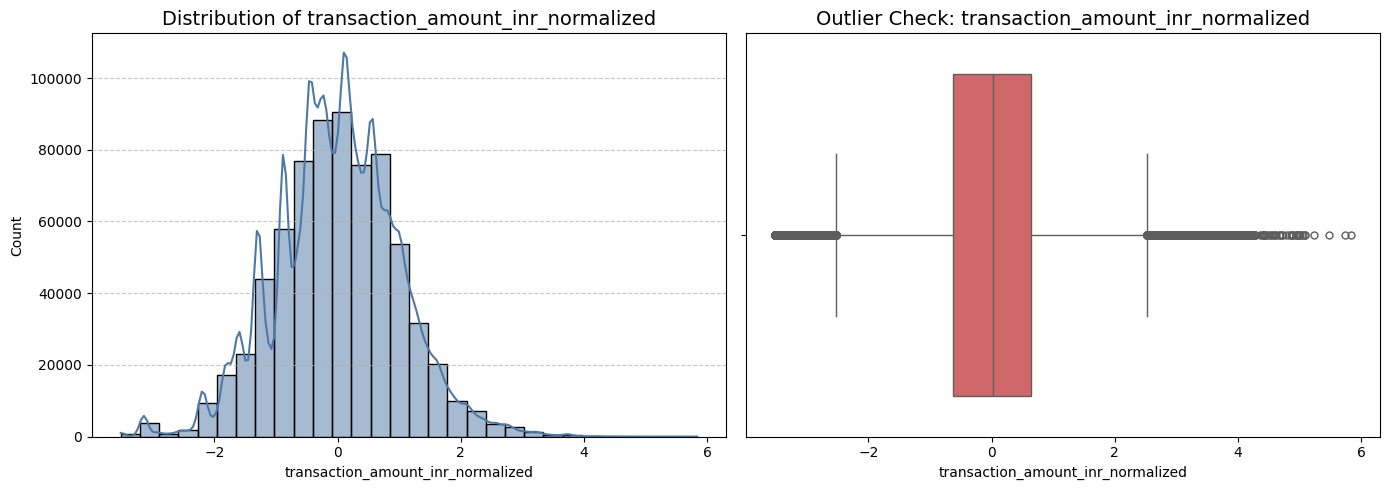

In [ ]:
# check distribution 

for col in df.columns:
    check_distribution(df, col)

# get frequency 

In [ ]:
# df['customer_freq'] = df.groupby('customer_id')['customer_id'].transform('count')

# encoding

In [ ]:
# Binary Gender Mapping (M=0, F=1)
df['gender_encoded'] = df['cust_gender'].map({'M': 0, 'F': 1})


In [ ]:
# Ordinal Age Mapping (Preserving the mathematical order of ages)
age_map = {'<18': 0, '18-24': 1, '25-34': 2, '35-44': 3, '45-54': 4, '55-64': 5, '65+': 6}
df['age_ordinal'] = df['age_category'].map(age_map)

In [ ]:
df['cust_location'] = df['cust_location'].replace('NEW DELHI', 'DELHI')

In [ ]:
# Location Grouping (Top 15 cities + 'OTHER' to avoid high cardinality)
top_locations = df['cust_location'].value_counts().nlargest(15).index
df['location_grouped'] = df['cust_location'].apply(lambda x: x if x in top_locations else 'OTHER')


In [ ]:
# One-Hot Encoding for Nominal Categories
# This creates columns like time_Morning, loc_Mumbai, etc.
df_final = pd.get_dummies(df, columns=['transaction_time_category', 'location_grouped'], prefix=['time', 'loc'])

In [ ]:
# extract temporal feat
df['transaction_day_of_week'] = df['transaction_date'].dt.dayofweek      # 0=Mon, 6=Sun
df['transaction_month'] = df['transaction_date'].dt.month
df['is_weekend'] = (df['transaction_date'].dt.dayofweek >= 5).astype(int)

In [ ]:
cols_to_drop = [
    'transaction_id', 'customer_date_of_birth',
    'transaction_date', 'transaction_time', 'cust_location',
    'cust_gender', 'age_category', 'age',
    'cust_account_balance', 'transaction_amount_inr', 'hour'
]
# note: customer_id is NOT dropped — keep it as an index

df_final = pd.get_dummies(df, columns=['transaction_time_category', 'location_grouped'], 
                          prefix=['time', 'loc'], drop_first=True)  # fixes dummy trap too

df_final = df_final.drop(columns=cols_to_drop, errors='ignore')

In [ ]:
df_final.head()

,customer_id,customer_freq,avg_txn_amount,total_txn_amount,cust_account_balance_normalized,transaction_amount_inr_normalized,gender_encoded,age_ordinal,transaction_day_of_week,transaction_month,is_weekend,time_Early Morning (04–08),time_Morning (08–12),time_Midday/Afternoon (12–16),time_Evening (16–20),time_Night (20–00),loc_BANGALORE,loc_CHENNAI,loc_DELHI,loc_FARIDABAD,loc_GHAZIABAD,loc_GURGAON,loc_HYDERABAD,loc_KOLKATA,loc_MUMBAI,loc_NAVI MUMBAI,loc_NEW DELHI,loc_NOIDA,loc_OTHER,loc_PUNE,loc_THANE
0,C5841053,1,25.0,25.0,0.043560,-1.695121,1,1,1,8,0,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False
1,C2142763,1,27999.0,27999.0,-0.787293,2.818036,0,5,1,8,0,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False
2,C4417068,1,459.0,459.0,0.044953,0.057444,1,1,1,8,0,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False
3,C9031234,1,1762.5,1762.5,-0.372588,0.926114,1,2,1,8,0,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False
4,C1536588,1,676.0,676.0,0.567597,0.303955,1,3,1,8,0,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False


# feat selection

In [ ]:
# Select only the continuous/ranked features
# We exclude the One-Hot binary columns (is_city, is_morning, etc.)
numerical_features = ['cust_account_balance_normalized', 'transaction_amount_inr_normalized', 'customer_freq', 'age_ordinal']

df_num = df_final[numerical_features]

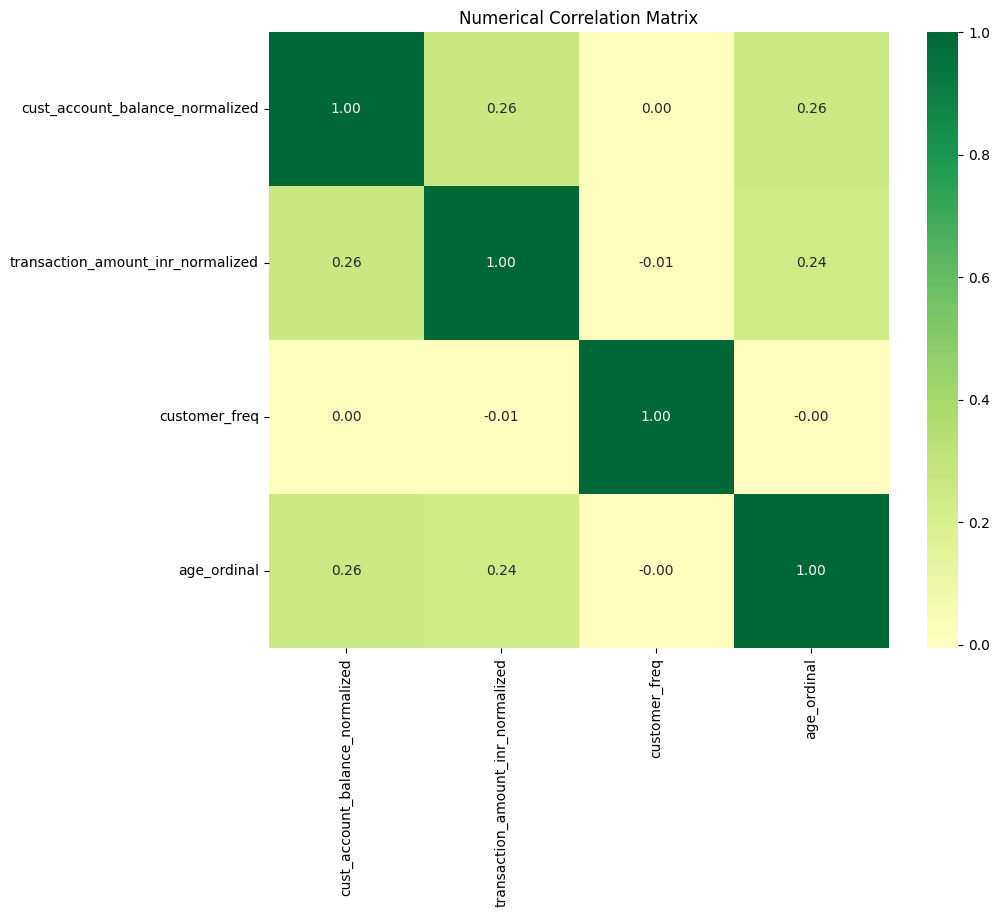

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(df_num.corr(), annot=True, cmap='RdYlGn', center=0, fmt=".2f")
plt.title("Numerical Correlation Matrix")
plt.show()


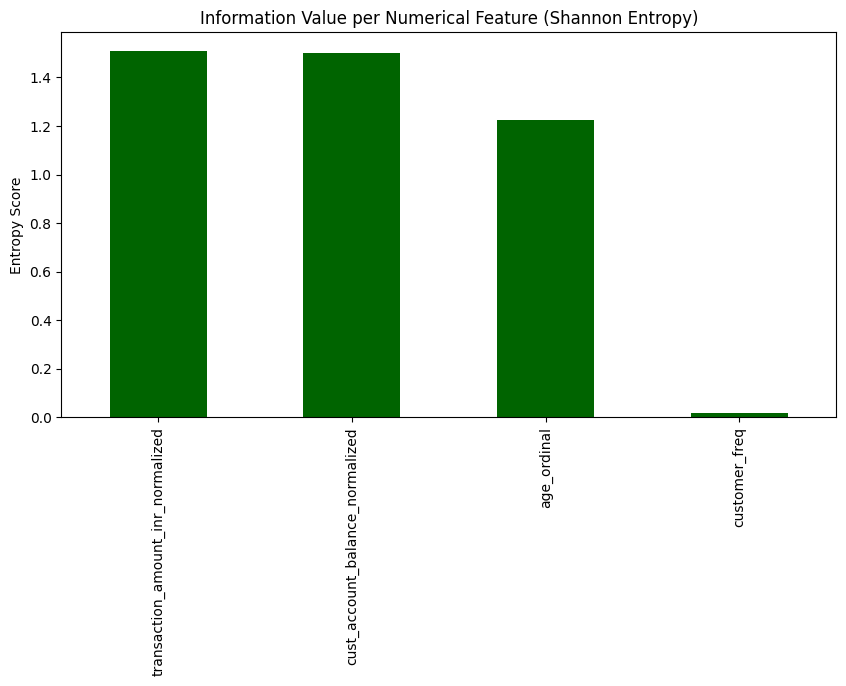

--- Numerical Information Rankings ---
transaction_amount_inr_normalized    1.510380
cust_account_balance_normalized      1.500122
age_ordinal                          1.223740
customer_freq                        0.017411
dtype: float64


In [ ]:
import numpy as np
from scipy.stats import entropy

def calculate_numerical_entropy(data, bins=10):
    # Calculates Shannon Entropy of a numerical column by binning it first
    hist, _ = np.histogram(data, bins=bins, density=True)
    return entropy(hist)

# Calculate for your numerical columns
num_entropy_scores = {col: calculate_numerical_entropy(df_num[col]) for col in df_num.columns}
num_entropy_results = pd.Series(num_entropy_scores).sort_values(ascending=False)

# Visualization
plt.figure(figsize=(10, 5))
num_entropy_results.plot(kind='bar', color='darkgreen')
plt.title("Information Value per Numerical Feature (Shannon Entropy)")
plt.ylabel("Entropy Score")
plt.show()

print("--- Numerical Information Rankings ---")
print(num_entropy_results)


> sepertinya tidak ada feature yang di drop karena walaupun ranking customer_freq itu kecil kita tetap butuh untuk minging angle kita dalam transaction rate dan yang lainnya aman, serta untuk kategorikal yang telah di encode semuanya teatp dibutuhkan sesuai mining angle nya

In [ ]:
ohe_cols = [c for c in df_final.columns if c.startswith(('time_', 'loc_'))]
df_final[ohe_cols] = df_final[ohe_cols].astype(int)

df_final.to_csv('clean.csv', index=False)  # index=False kills Unnamed: 0